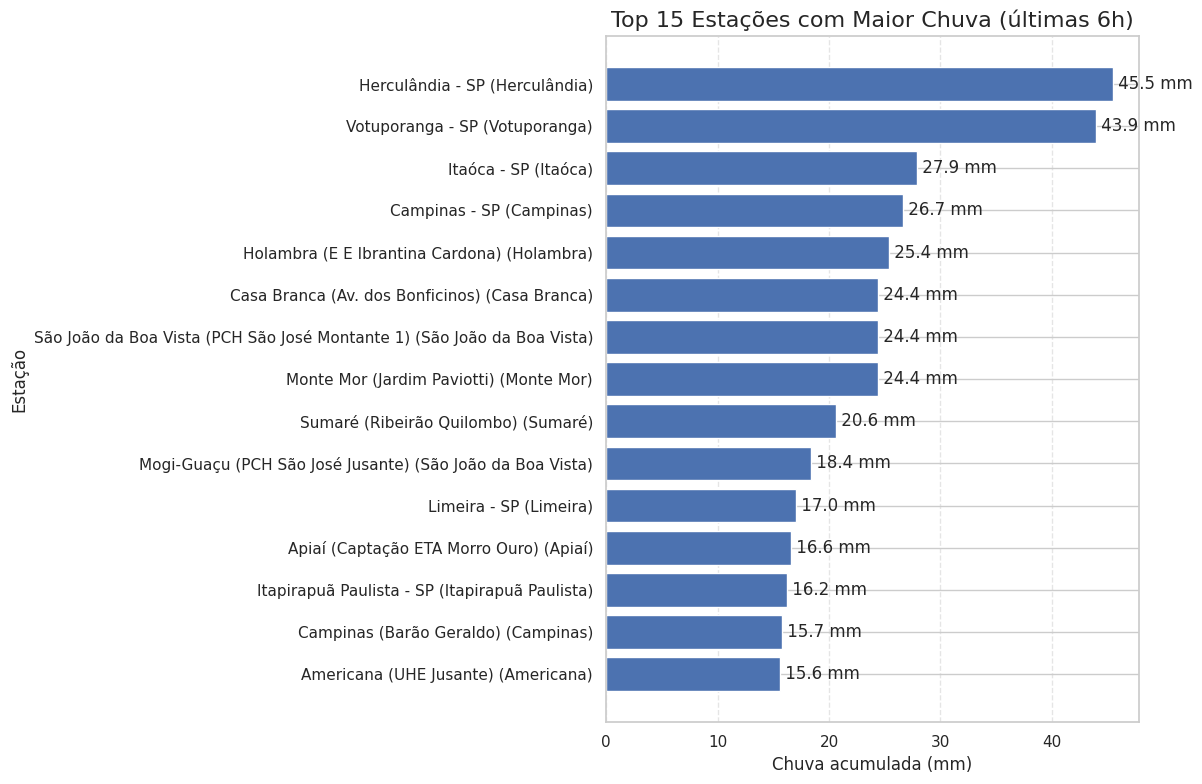

In [9]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1) Coleta
# ----------------------------
url = "https://apps.spaguas.sp.gov.br/sibh/api/v2/measurements/now"

params = {
    "station_type_id": 2,
    "hours": 12,
    "show_all": "false",
    "serializer": "complete",
    "public": "true"
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

data = response.json()["measurements"]

# ----------------------------
# 2) DataFrame
# ----------------------------
df = pd.json_normalize(data)

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])

df["label"] = df["station_name"] + " (" + df["city"] + ")"

df_top = df.sort_values("value", ascending=False).head(15)

# ----------------------------
# 3) Plot
# ----------------------------
plt.figure(figsize=(12, 8))

bars = plt.barh(df_top["label"], df_top["value"])
plt.gca().invert_yaxis()

plt.title("Top 15 Estações com Maior Chuva (últimas 6h)", fontsize=16)
plt.xlabel("Chuva acumulada (mm)")
plt.ylabel("Estação")

# valores nas barras
for i, v in enumerate(df_top["value"]):
    plt.text(v, i, f" {v:.1f} mm", va="center")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

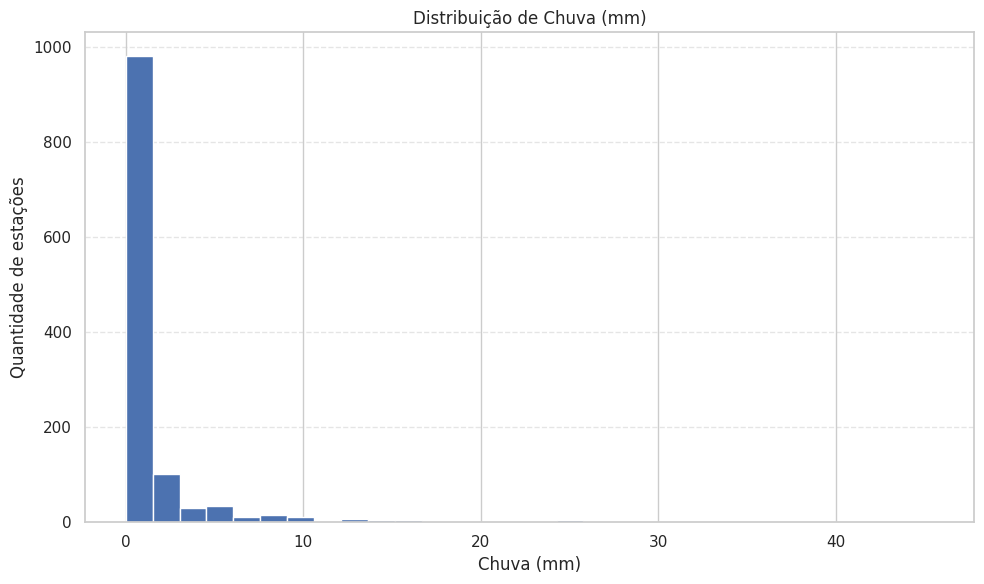

In [10]:
plt.figure(figsize=(10, 6))

plt.hist(df["value"], bins=30)

plt.title("Distribuição de Chuva (mm)")
plt.xlabel("Chuva (mm)")
plt.ylabel("Quantidade de estações")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

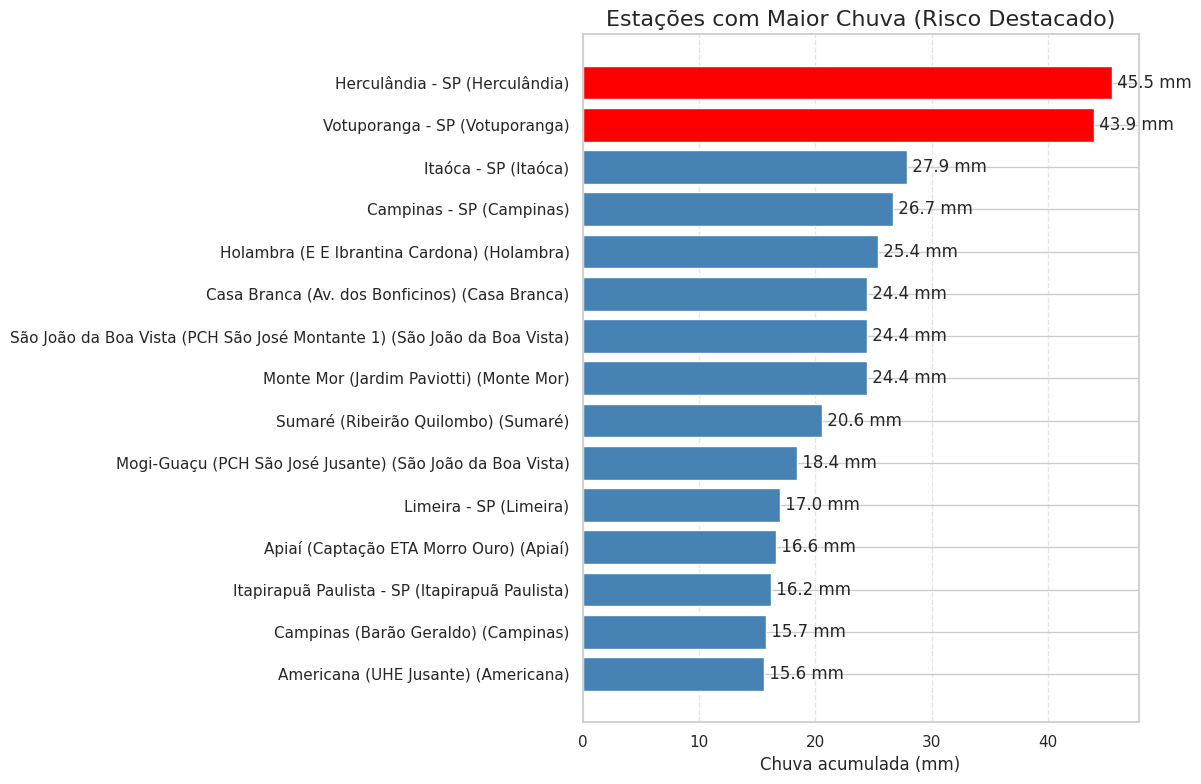

In [11]:
plt.figure(figsize=(12, 8))

colors = ["red" if v > 30 else "steelblue" for v in df_top["value"]]

bars = plt.barh(df_top["label"], df_top["value"], color=colors)
plt.gca().invert_yaxis()

plt.title("Estações com Maior Chuva (Risco Destacado)", fontsize=16)
plt.xlabel("Chuva acumulada (mm)")

for i, v in enumerate(df_top["value"]):
    plt.text(v, i, f" {v:.1f} mm", va="center")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()